# Money Market Rates


# Data

Use the data in `data/ref_rates.xlsx` to explore several key money-market rates.
* SOFR
* Fed funds
* 3-month T-bill yield

***

# 1. Exploring Money-Market Rates

### 1.
Plot the time series.

### 2.
Calculate the correlation between the three rates (filtering to the dates for which they all have reported values.)

Do this correlation analysis for the data in
* levels (as provided)
* differences (day-over-day changes)

### 3.

Estimate an autoregression for SOFR:

$$r_{t} = \alpha + \beta\, r_{t-1} + \epsilon_{t}$$

Report the estimated regression beta and r-squared.

Comment on what this regression tells us about the nature of interest rates. 
* That is, can we forecast the next period's rate? 
* Does the series have **autocorrelation**?

### 4.

Estimate an autoregression for returns of the S&P 500 ETF, `SPY`, rather than using SOFR. Get data from 
* `data/spy_data_daily.xlsx`

Are SPY returns autocorrelated? And SPY prices?

***
## Setup


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from pathlib import Path

def datafile(name):
    """Locate a data file whether this notebook sits beside data/ or below it."""
    for base in (Path('data'), Path('../data'), Path('../../data'), Path('.')):
        if (base / name).exists():
            return base / name
    raise FileNotFoundError(f'could not find {name} in data/, ../data/, ../../data/ or .')

FILEPATH = datafile('ref_rates.xlsx')

info = pd.read_excel(FILEPATH, sheet_name='info')
rates = pd.read_excel(FILEPATH, sheet_name='data', index_col=0)

LABELS = {'SOFR': 'SOFR', 'DFF': 'Fed funds effective', 'DTB3': '3-month T-bill'}

display(info)
rates.head()

,description,ticker (FRED)
0,Tbill 3-month,DTB3
1,Fed Funds Effective,DFF
2,SOFR,SOFR


,DTB3,DFF,SOFR
date,,,
2018-01-01,NaN,1.33,NaN
2018-01-02,1.42,1.42,NaN
2018-01-03,1.39,1.42,NaN
2018-01-04,1.39,1.42,NaN
2018-01-05,1.37,1.42,NaN


In [10]:
# how much data does each series actually have?
pd.DataFrame({
    'first obs': rates.apply(lambda s: s.first_valid_index()),
    'last obs': rates.apply(lambda s: s.last_valid_index()),
    'n obs': rates.notna().sum(),
    'n missing': rates.isna().sum(),
})

,first obs,last obs,n obs,n missing
DTB3,2018-01-02,2026-06-04,2106,972
DFF,2018-01-01,2026-06-04,3077,1
SOFR,2018-04-03,2026-06-05,2042,1036


SOFR only begins in April 2018 (it was introduced that month), and the T-bill series is missing on non-trading days, so the three series do not cover identical date ranges. That matters for question 2.


***
### 1. Plot the time series


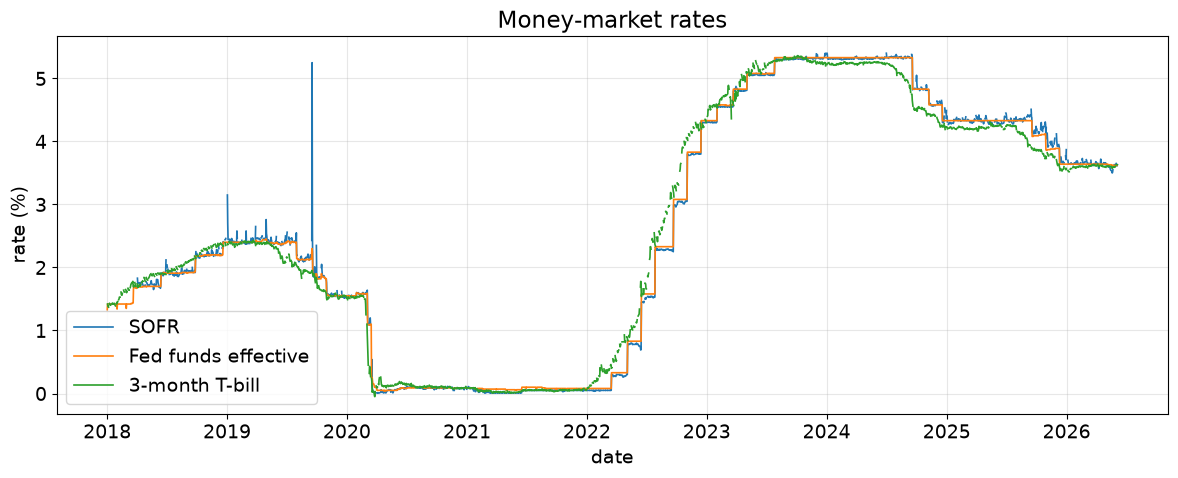

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

for col in ['SOFR', 'DFF', 'DTB3']:
    ax.plot(rates.index, rates[col], label=LABELS[col], lw=1.2)

ax.set_title('Money-market rates')
ax.set_xlabel('date')
ax.set_ylabel('rate (%)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

All three rates track each other closely: near zero through 2018-2019, collapsing to the floor in March 2020, the rapid 2022-2023 hiking cycle up to roughly 5%, then easing from late 2024. The 3-month bill leads the other two at turning points, since it prices expectations over the coming quarter rather than the overnight rate today.


***
### 2. Correlations, in levels and in differences


In [12]:
# filter to dates where all three have reported values
common = rates.dropna()

print(f'observations with all three series: {len(common)}')
print(f'date range: {common.index.min().date()} to {common.index.max().date()}')

observations with all three series: 2041
date range: 2018-04-03 to 2026-06-04


In [13]:
corr_levels = common.corr()
corr_levels.style.format('{:.4f}').set_caption('Correlation - levels')

,DTB3,DFF,SOFR
DTB3,1.0000,0.9947,0.9929
DFF,0.9947,1.0000,0.9991
SOFR,0.9929,0.9991,1.0000


In [14]:
corr_diffs = common.diff().dropna().corr()
corr_diffs.style.format('{:.4f}').set_caption('Correlation - daily differences')

,DTB3,DFF,SOFR
DTB3,1.0000,0.0080,0.0375
DFF,0.0080,1.0000,0.4965
SOFR,0.0375,0.4965,1.0000


**In levels** all three correlations are above 0.99 — the series look almost identical. But this is largely spurious: each series is highly persistent and they share one big common trend (the hiking cycle). Correlating two trending series mostly measures the fact that both trended.

**In differences** the picture changes completely. SOFR and fed funds still move together (about 0.50) because both are overnight rates responding to the same funding conditions. But the T-bill's correlation with either overnight rate drops to roughly 0.01–0.04 — essentially nothing. Day to day, the 3-month bill is driven by shifting expectations of *future* Fed policy, while the overnight rates are pinned near the current target. The levels correlation hid all of this.

This is the standard reason to difference before correlating persistent time series.


***
### 3. Autoregression for SOFR

$$r_{t} = \alpha + \beta\, r_{t-1} + \epsilon_{t}$$


In [15]:
sofr = rates['SOFR'].dropna()

X = sm.add_constant(sofr.shift(1).dropna().rename('SOFR lag'))
y = sofr.loc[X.index]

ar_sofr = sm.OLS(y, X).fit()

print(f'alpha     = {ar_sofr.params.iloc[0]:.5f}')
print(f'beta      = {ar_sofr.params.iloc[1]:.5f}')
print(f'r-squared = {ar_sofr.rsquared:.5f}')
print(f'n         = {int(ar_sofr.nobs)}')

alpha     = 0.00480
beta      = 0.99852
r-squared = 0.99700
n         = 2041


In [16]:
ar_sofr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   SOFR   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 6.782e+05
Date:                Mon, 03 Aug 2026   Prob (F-statistic):               0.00
Time:                        15:06:48   Log-Likelihood:                 1668.3
No. Observations:                2041   AIC:                            -3333.
Df Residuals:                    2039   BIC:                            -3321.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0048      0.004      1.204      0.229      -0.003       0.013
SOFR lag       0.9985      0.001    823.538      0.000       0.996       1.001
==============================================================================
Omnibus:                     1463.919   Durbin-Watson:                   2.498
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         16654309.016
Skew:                           1.499   Prob(JB):                         0.00
Kurtosis:                     445.525   Cond. No.                         5.89
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Comment.** Beta is about 0.9985 — almost exactly 1 — and the r-squared is about 0.997. So yes, the series is enormously autocorrelated: today's SOFR explains 99.7% of the variation in tomorrow's.

But this is not a forecasting result, and it would be a mistake to read it as one. A beta of essentially 1 means the fitted model is close to a random walk, $r_t \approx r_{t-1}$. The "forecast" it produces is just *today's rate*. The regression tells us rates are highly persistent — they don't jump around — not that we have any real predictive power over where they go next.

The right way to see this: the model explains almost none of the *change* in the rate. Rearranging, $r_t - r_{t-1} = \alpha + (\beta - 1) r_{t-1} + \epsilon_t$, and $\beta - 1 \approx -0.0015$. Regressing the daily change on the lagged level gives an r-squared near zero:


In [17]:
# same regression, written in terms of the daily change
dy = (sofr - sofr.shift(1)).loc[X.index]
ar_change = sm.OLS(dy, X).fit()

print(f'beta on lagged level = {ar_change.params.iloc[1]:.5f}')
print(f'r-squared            = {ar_change.rsquared:.5f}')

beta on lagged level = -0.00148
r-squared            = 0.00073


An r-squared this small confirms the point: the level is predictable only in the trivial sense that it barely moves. The high r-squared in the original regression comes from the persistence of the level, not from genuine forecastability.


***
### 4. Autoregression for SPY returns (and prices)


In [18]:
SPY_FILEPATH = datafile('spy_data_daily.xlsx')

spy_rets = pd.read_excel(SPY_FILEPATH, sheet_name='total returns', index_col=0)['SPY'].dropna()
spy_px = pd.read_excel(SPY_FILEPATH, sheet_name='prices', index_col=0)['SPY'].dropna()

print(f'returns: {len(spy_rets)} obs, {spy_rets.index.min().date()} to {spy_rets.index.max().date()}')
spy_rets.head()

returns: 8165 obs, 1994-01-04 to 2026-06-12


date
1994-01-04    0.004035
1994-01-05    0.002010
1994-01-06    0.000000
1994-01-07    0.006015
1994-01-10    0.011960
Name: SPY, dtype: float64

In [19]:
def ar1(series, name):
    """Estimate r_t = alpha + beta r_{t-1} + e_t and report beta / r-squared."""
    X = sm.add_constant(series.shift(1).dropna().rename('lag'))
    y = series.loc[X.index]
    fit = sm.OLS(y, X).fit()
    return pd.Series({
        'alpha': fit.params.iloc[0],
        'beta': fit.params.iloc[1],
        't-stat (beta)': fit.tvalues.iloc[1],
        'r-squared': fit.rsquared,
        'n': int(fit.nobs),
    }, name=name)

results = pd.DataFrame([
    ar1(spy_rets, 'SPY returns'),
    ar1(spy_px, 'SPY prices'),
    ar1(sofr, 'SOFR'),
]).T

results

,SPY returns,SPY prices,SOFR
alpha,0.000519,-0.016158,0.004804
beta,-0.082877,1.000590,0.998519
t-stat (beta),-7.513221,5829.896318,823.537571
r-squared,0.006869,0.999760,0.997003
n,8164.000000,8165.000000,2041.000000


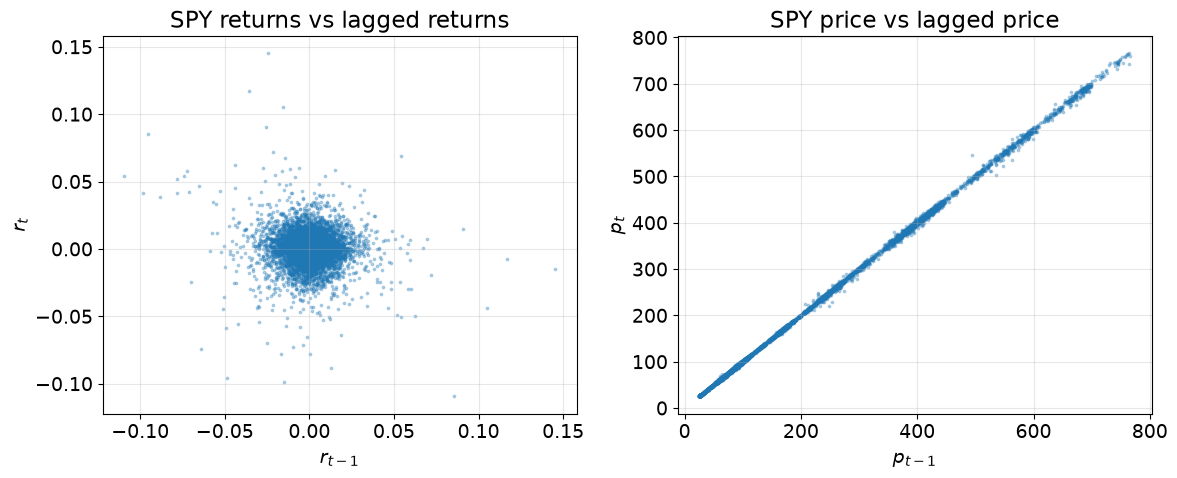

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(spy_rets.shift(1), spy_rets, s=3, alpha=0.3)
axes[0].set_title('SPY returns vs lagged returns')
axes[0].set_xlabel('$r_{t-1}$')
axes[0].set_ylabel('$r_t$')

axes[1].scatter(spy_px.shift(1), spy_px, s=3, alpha=0.3)
axes[1].set_title('SPY price vs lagged price')
axes[1].set_xlabel('$p_{t-1}$')
axes[1].set_ylabel('$p_t$')

for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Are SPY returns autocorrelated?** Essentially no. Beta is about $-0.083$ with an r-squared of about $0.007$ — under 1% of tomorrow's return is explained by today's. The slight negative sign is the familiar short-horizon reversal effect, and with ~8,000 observations it is statistically distinguishable from zero, but it is economically tiny and would not survive transaction costs. Returns are close to unforecastable, which is what an efficient market implies.

**Are SPY prices autocorrelated?** Overwhelmingly yes. Beta is about $1.0006$ with an r-squared of about $0.9998$ — the price series is a near-perfect random walk.

**The contrast is the whole lesson.** Prices and rates are both highly autocorrelated *levels*; returns are the *changes*. The high r-squared on prices tells us nothing tradeable, exactly as with SOFR in question 3 — the best guess of tomorrow's price is today's price. All the useful information lives in the changes, and there the predictability essentially vanishes.

Note the asymmetry with rates, though: SOFR's *changes* are near-unforecastable too, but rates are mean-reverting over long horizons in a way prices are not, since the Fed steers them toward a target.
